<a href="https://colab.research.google.com/github/nawab-khan/ovs-thesis/blob/main/notebooks/day1_grounded_sam_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install torch torchvision transformers accelerate opencv-python supervision matplotlib segment_anything
%pip install -U supervision

In [ ]:
import torch
import requests
from transformers import pipeline
from segment_anything import sam_model_registry, SamPredictor
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from supervision import BoxAnnotator, MaskAnnotator

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
# NEW (replace with this):
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

model_id = "IDEA-Research/grounding-dino-tiny"
processor = AutoProcessor.from_pretrained(model_id)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(DEVICE)

print("✓ GroundingDINO (AutoModel) loaded")


The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

✓ GroundingDINO (AutoModel) loaded


In [ ]:
# --- CELL: Download SAM ViT‑H checkpoint in Colab ---
import os
import torch
from segment_anything import sam_model_registry, SamPredictor

# 1. Install segment_anything if not done already
!pip install git+https://github.com/facebookresearch/segment-anything.git

# 2. Download SAM ViT‑H checkpoint (Colab)
SAM_CHECKPOINT = "sam_vit_h_4b8939.pth"
if not os.path.exists(SAM_CHECKPOINT):
    print("Downloading SAM ViT‑H checkpoint...")
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -O {SAM_CHECKPOINT}
    print(f"Downloaded {SAM_CHECKPOINT}")
else:
    print(f"{SAM_CHECKPOINT} already exists.")

# 3. Load SAM model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT)
sam.to(device=DEVICE)
predictor = SamPredictor(sam)


  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-mb8t9n3u
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-mb8t9n3u
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
sam_vit_h_4b8939.pth already exists.
Using device: cuda


In [ ]:
# # =============================================================================
# REPLACE your GroundedSAMPipeline class WITH THIS:
# =============================================================================

class GroundedSAMPipeline:
    """Modular baseline: TEXT → GroundingDINO → Boxes → SAM → Masks"""

    def __init__(self, processor, model, sam_predictor, device):
        self.processor = processor
        self.model = model
        self.predictor = sam_predictor
        self.device = device
        self._image_hash = None

    def detect(self, image_pil, text_prompt, box_threshold=0.25, text_threshold=0.25):
        """GroundingDINO detection with proper label parsing."""
        inputs = self.processor(images=image_pil, text=text_prompt, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)

        results = self.processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=box_threshold,
            text_threshold=text_threshold,
            target_sizes=[image_pil.size[::-1]]
        )

        result = results[0]
        return (
            result["boxes"].cpu().numpy(),
            result["scores"].cpu().numpy(),
            # result["labels"]
            result["text_labels"]
        )

    def segment(self, image_np, boxes):
        """SAM segmentation for each box."""
        if boxes.shape[0] == 0:
            return np.empty((0, image_np.shape[0], image_np.shape[1]))

        h, w = image_np.shape[:2]
        curr_hash = hash((h, w, id(image_np)))
        if self._image_hash != curr_hash:
            self.predictor.set_image(image_np)
            self._image_hash = curr_hash

        masks_list = []
        for box in boxes:
            mask, _, _ = self.predictor.predict(
                point_coords=None, point_labels=None,
                box=box.astype(np.float32), multimask_output=False
            )
            mask = mask.squeeze(0) if mask.ndim == 3 else mask
            masks_list.append(mask)

        return np.stack(masks_list, axis=0)

    def run(self, image_pil, text_prompt, box_threshold=0.25):
        """End-to-end pipeline."""
        boxes, scores, labels = self.detect(image_pil, text_prompt, box_threshold)
        image_np = np.array(image_pil.convert("RGB"))[..., ::-1]  # RGB → BGR
        masks = self.segment(image_np, boxes)

        return {
            "image_np": image_np,
            "boxes": boxes,
            "scores": scores,
            "labels": labels,
            "masks": masks
        }

    def visualize(self, result, show_boxes=True, show_masks=True, figsize=(14, 6)):
        """Visualize detections + masks."""
        image_rgb = cv2.cvtColor(result["image_np"], cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]

        scale = 800 / max(h, w) if max(h, w) > 800 else 1.0
        disp = cv2.resize(image_rgb, (int(w*scale), int(h*scale))) if scale < 1.0 else image_rgb

        fig, axes = plt.subplots(1, 2 if show_masks else 1, figsize=figsize)
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])

        # Boxes
        axes[0].imshow(disp)
        axes[0].set_title("Open-Vocabulary Detections (GroundingDINO)")

        for box, score, label in zip(result["boxes"] * scale, result["scores"], result["labels"]):
            x1, y1, x2, y2 = box.astype(int)
            axes[0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor="cyan", facecolor="none", linewidth=2))
            axes[0].text(x1, y1-5, f"{label} ({score:.2f})", color="cyan", fontsize=9, fontweight="bold",
                        bbox=dict(boxstyle="round", facecolor="cyan", alpha=0.3))
        axes[0].axis("off")

        # Masks
        if show_masks:
            axes[1].imshow(disp)
            axes[1].set_title("Segmentation Masks (SAM)")
            for mask in result["masks"]:
                mask = mask.squeeze(0) if mask.ndim == 3 else mask
                axes[1].imshow(mask, cmap="gray", alpha=0.35)
                axes[1].contour(mask, colors="yellow", linewidths=1)
            axes[1].axis("off")

        plt.tight_layout()
        plt.show()


Detected 6 objects:
  a cat: 0.507
  a remote control: 0.480
  a remote control: 0.391
  a blanket: 0.409
  a cat: 0.490
  a blanket: 0.277


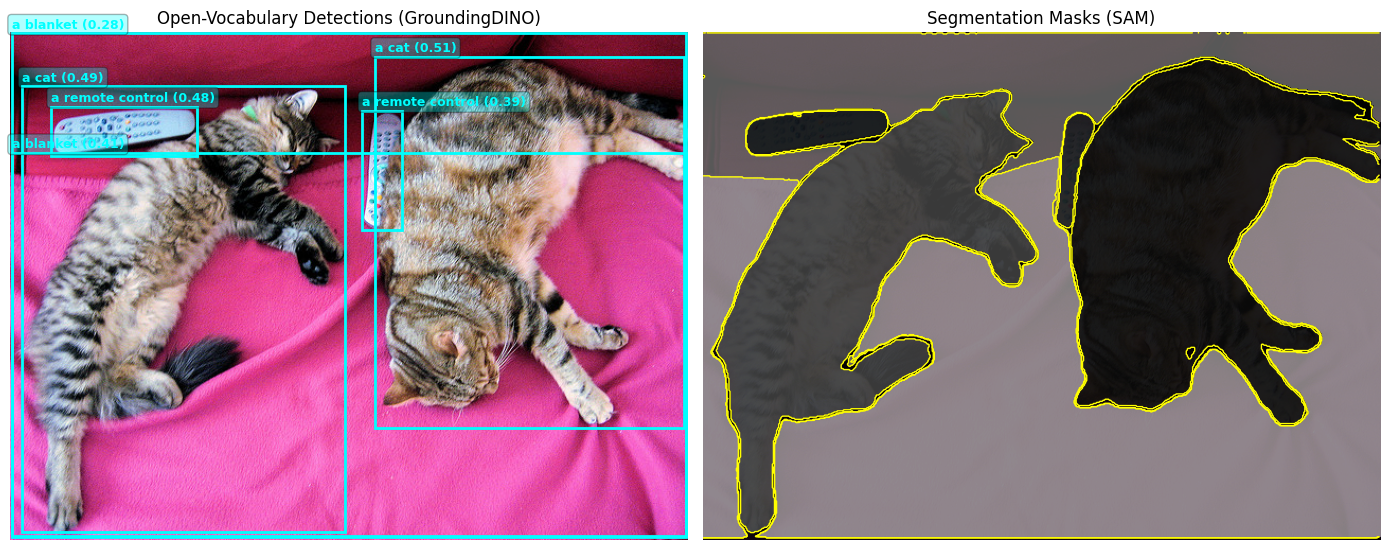

In [ ]:
# Initialize pipeline
# pipeline = GroundedSAMPipeline(detector, predictor, DEVICE)

# NEW initialization:
pipeline = GroundedSAMPipeline(processor, grounding_model, predictor, DEVICE)


# Load image (URL or local)
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image_pil = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# Run open-vocabulary instance segmentation
text_prompt = "a cat. a remote control. a blanket."
result = pipeline.run(image_pil, text_prompt, box_threshold=0.25)

print(f"Detected {len(result['labels'])} objects:")
for label, score in zip(result["labels"], result["scores"]):
    print(f"  {label}: {score:.3f}")

# Visualize
pipeline.visualize(result, show_boxes=True, show_masks=True)
